# Réduction de volume de données océaniques - Température de surface
**Résolution d'un problème opérationnel**

En mer, le besoin d'information d'état de mer est primordial pour de nombreux aspects (détection, navigation, calibration). Ce besoin implique le transfert de nombres de données qui ne peuvent être calculées directement à bord. Pour avoir accès à ces informations les bâtiments font appel au transfert par satellites, qui limites considérabelment la quantité de données qui est accessible en continue.

Il est possible de mettre en œuvres de stratégies pour réduire la taille des données a envoyer, mais la réduction de leur dimension a un coup : la qualité de l'information. Les recherches se focalisent donc sur comment obtenir la meilleure reconstruction avec le coup de données le plus faible.

Nous travaillerons sur des données Mercator Glorys au 12°ème de degrés sur l'Atlantique Sud. Que nous prendrdons en mains dans un premier temps, puis les utiliserons pour tester différentes méthodes de réduction de données.


**Contenu de l'atelier**
- Présentation des données, comment les obtenir, travailler avec des fichiers `.nc`
- Prétraitement pour extraire les variables d'intérêt et préparation des Dataset
- Présentation des Méthodes utilisées
- Application de la décomposition ACP (PCA ou EOF)
- Dataset PyTorch et DataLoader
- Modèles : Auto-Encodeur convolutionnel (AE) et U-Net
- Entraînement avec PyTorch Lightning
- Sauvegarde / chargement des modèles
- Visualisations : outil pour conclure sur la problématique


> Remarque : L'ensemble du corrigé vous sera fournis en fin de cours.


# 1) Installations (si nécessaire)

## On prend en mains l'environnement python
Création de l'environnement python avec une fichier de `requierment.yml` avec conda.
Importation des bibliothèques necessaires pour l'ensemble de la journée.

conda env create -f environmentuni.yml -n nouveau_nom                                   

## Imports

In [3]:
import os
import glob
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import datetime as dt
from tqdm import trange
from ipywidgets import interact, IntSlider

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar

from sklearn.decomposition import PCA

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#!ls "/content/drive/My Drive"

# 2) Prise en mains des fichiers GLORYS12

## Chargement des fichiers .nc

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pathdir = "/content/drive/MyDrive/Ateliershom/previ/"
ds = xr.open_dataset(f"{pathdir}glorys12_1day_2023-01-01.nc")

ds

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 1, depth: 50, latitude: 121, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 8B 2023-01-01
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
  * longitude  (longitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 6MB ...
Attributes:
    Conventions:  CF-1.4
    institution:  MERCATOR OCEAN
    references:   http://www.mercator-ocean.fr
    source:       MERCATOR GLORYS12V1
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    comment:      CMEMS product
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation

## Dimensions coordonnées et variables

In [ ]:
# Coordonées du nc
print("Coordonnées :", list(ds.coords))
print("Dimensions :", ds.dims)
# Variables présentes
print("Variables :", list(ds.data_vars))


Coordonnées : ['depth', 'latitude', 'longitude', 'time']
Dimensions : FrozenMappingWarningOnValuesAccess({'time': 1, 'depth': 50, 'latitude': 121, 'longitude': 121})
Variables : ['thetao']


## Description des grilles et unités

In [ ]:
lon_min, lon_max = float(ds['longitude'].min()), float(ds['longitude'].max())
lat_min, lat_max = float(ds['latitude'].min()), float(ds['latitude'].max())
depth_min, depth_max = float(ds['depth'].min()), float(ds['depth'].max())
depth_unit = ds['depth'].attrs.get('units', 'non spécifiée')

print(f"Grille longitudinale : {lon_min}° à {lon_max}°")
print(f"Grille latitudinale  : {lat_min}° à {lat_max}°")
print(f"Profondeur            : {depth_min} à {depth_max} {depth_unit}")

Grille longitudinale : -40.0° à -30.0°
Grille latitudinale  : -40.0° à -30.0°
Profondeur            : 0.49402499198913574 à 5727.9169921875 m


## Exemple d'inspection d'une variable

In [ ]:
def descript_variable(var):
    print("Nom long :", var.attrs.get('long_name', ''))
    print("Nom standard :", var.attrs.get('standard_name', ''))
    print("Unité :", var.attrs.get('units', ''))
    print("Dimensions :", var.dims)
    print("Shape :", var.shape)
    return

In [ ]:
var = "thetao"

In [ ]:
descript_variable(ds[var])

Nom long : Temperature
Nom standard : sea_water_potential_temperature
Unité : degrees_C
Dimensions : ('time', 'depth', 'latitude', 'longitude')
Shape : (1, 50, 121, 121)


## Visualisation 2D

In [ ]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


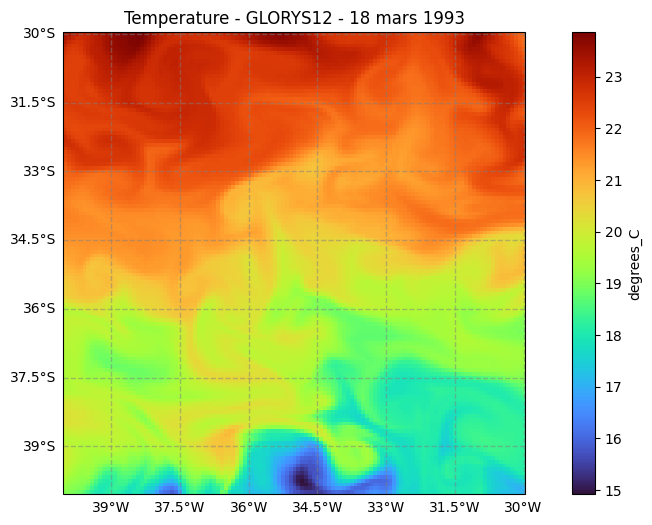

In [ ]:
var_surface = ds[var].isel(depth=2, time=0)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

var_surface.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='turbo',
    add_colorbar=True,
    cbar_kwargs={'label': ds[var].attrs.get('units', '')},
    add_labels=False
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Titre
ax.set_title(f"{var_surface.attrs.get('long_name', '')} - GLORYS12 - 18 mars 1993")

plt.show()


## Profil vertical

In [ ]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

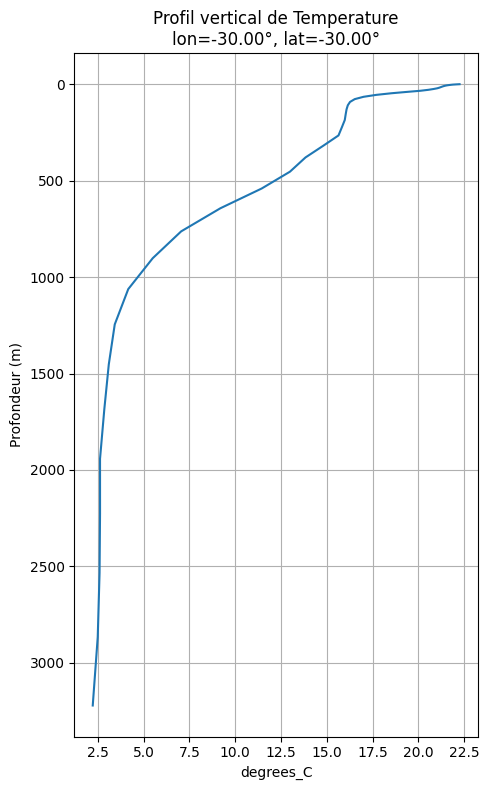

In [ ]:
# à adapter
lon_target = -30.0  # exemple : 30°O
lat_target = 45.0   # exemple : 45°N

# Si indice non grillé, on recherhce le plus proche
lon_idx = abs(ds['longitude'] - lon_target).argmin().item()
lat_idx = abs(ds['latitude'] - lat_target).argmin().item()

# Choix de la variable ['so', 'thetao', 'uo', 'vo', 'zos']
var_profil = ds[var]
profil = var_profil.isel(
    time=0,
    longitude=lon_idx,
    latitude=lat_idx
)

plt.figure(figsize=(5, 8))
plt.plot(profil, ds['depth'])
plt.gca().invert_yaxis()
plt.xlabel(ds[var].attrs.get('units', ''))
plt.ylabel("Profondeur (m)")
plt.title(f"Profil vertical de {var_profil.attrs.get('long_name', '')}\nlon={ds['longitude'][lon_idx].item():.2f}°, lat={ds['latitude'][lat_idx].item():.2f}°")
plt.grid()
plt.tight_layout()
plt.show()

## Autre visualisation : Coupe dans la colonne d'eau

In [ ]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

/tmp/ipython-input-119421488.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  idx_lat = ds.dims['latitude'] // 2


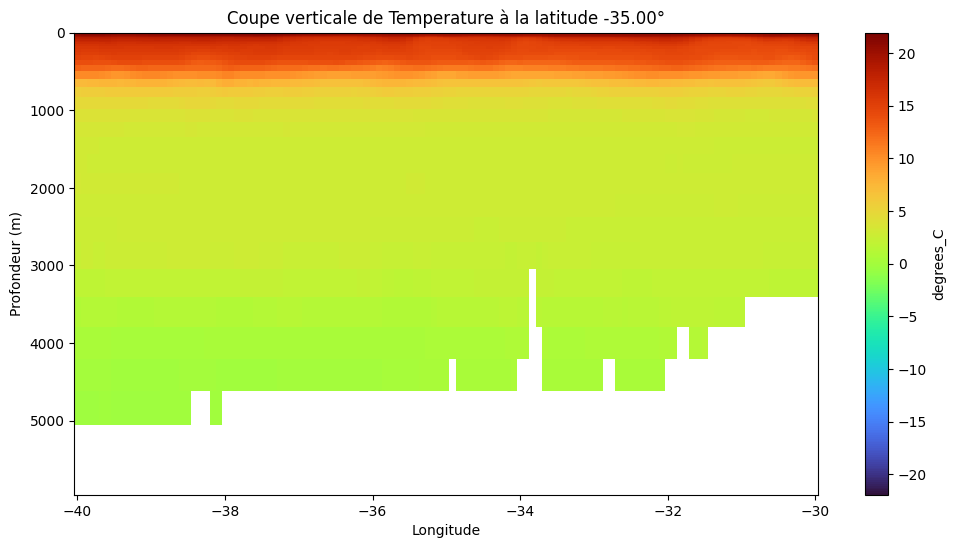

In [ ]:
# On coupe à la moitié de la latitude
idx_lat = ds.dims['latitude'] // 2
lat_val = ds['latitude'].isel(latitude=idx_lat).values

var_section = ds[var].isel(latitude=idx_lat, time=0)

var_section.plot(
    x='longitude',
    y='depth',
    yincrease=False,  # profondeur vers le bas
    cmap='turbo',
    figsize=(12, 6),
    cbar_kwargs={'label': ds[var].attrs.get('units', '')}
)
plt.title(f"Coupe verticale de {var_section.attrs.get('long_name', '')} à la latitude {lat_val:.2f}°")
plt.xlabel("Longitude")
plt.ylabel("Profondeur (m)")
plt.show()

# 3) Définitions des méthodes mises en oeuvres

Maintenant que nous connaissons un peut mieux nos données, il est temps de savoir ce qu'on l'on peut faire pour répondre au problème.

Deux méthodes ont attiré notre attention :
- Une méthode linéaire, l'Analyse en composante principale (ACP)
- Une série de méthodes, les Auto-encoders (Conv, U-net ect...)

### ACP
L’Analyse en Composantes Principales (ACP) est une méthode de réduction de dimension qui projette des données initiales dans un espace de dimension plus faible tout en conservant le maximum d’information (variance).

En Océanographie les ACp sont utilisé pour décrire et analyser les processus physiques de champs 2D.  

**Formulation et équationsµ**

Soit un jeu de données centré $( X \in \mathbb{R}^{n \times p} )$.

1. **Matrice de covariance :**
$[
C = \frac{1}{n-1} X^\top X
]$

2. **Décomposition spectrale :**
$[
C = V \Lambda V^\top
]$
- $( V )$ contient les vecteurs propres (axes principaux)
- $( \Lambda )$ contient les valeurs propres (variance expliquée)

3. **Projection des données :**
$[
Z = X V_k
]$
où $( V_k )$ contient les $( k )$ vecteurs propres associés aux plus grandes valeurs propres.

L’ACP permet :
- de résumer l’information essentielle,
- de réduire le bruit,
- d’obtenir une visualisation en 2D des "processus les plus importants

![PCA .gif](https://miro.medium.com/v2/resize:fit:720/format:webp/1*37a_i1t1tDxDYT3ZI6Yn8w.gif)


#### AE
Un **autoencoder** est un réseau de neurones conçu pour apprendre une **représentation compacte** (appelée *latent space*) d’un ensemble de données, puis à reconstruire ces données le plus fidèlement possible.

Un autoencoder est composé en réalité de deux modèles :

### 1. **Encodeur**
Transforme les données d’entrée \( x \) en une représentation comprimée \( z \).

$
z = f_{\theta}(x)
$

où :
- $( f_{\theta} )$ est un réseau de neurones paramétré par $( \theta )$,
- $( z \in \mathbb{R}^k )$ avec $( k \ll \text{dim}(x) )$.

### 2. **Décodeur**
Reconstruit les données d’entrée à partir de la représentation latente :

$
\hat{x} = g_{\phi}(z)
$

où $( g_{\phi} )$ est le réseau inverse (décodeur).

### 3. **Fonction de coût**
Minimiser l’erreur de reconstruction :

$
L(x, \hat{x}) = \|x - \hat{x}\|^2
$

En résumé, il existe plusieurs manière de concevoir un Ae selon son but, reduction de dimension, reconstruction de données, debruitage ect...
Ce type d'architecture est extrémement pertinent avec les problématique liée aux champs spatiaux.

![variational-autoencoder-neural-network.png](https://www.researchgate.net/publication/354697586/figure/fig7/AS:1070344928505856@1632201525026/The-proposed-neural-network-architecture-of-variational-autoencoder-VAE-for-mass.png)

# 4) Préparation des données et lancement des traitements

## 4a) Prétraitement et lancement des ACP

On cherche à créer un dataset avec 3000 jours de données de SST sur notre zone. Le meilleur format pour travailler avec les méthodes ACP forunis par sklearn est le format numpy array.

L'objectif est d'obtenir une array de taille (3000,121,121) contenant l'ensemble des données de température journalière.

Il faudra également créer un jeu de données de validation, non utilisé dans l'apprentissage, celui ci correspond à l'année 2023, à part dans le jeu de données.

In [ ]:
# === Configuration ===
data_dir = "/content/drive/MyDrive/Ateliershom/train_reduced/"
max_files = 1008   # mettre un petit nombre pour test rapide (ex: 100)
date = dt.datetime(1993,3,28)
th2d= np.empty(shape=(max_files,121,121))

for i in trange(max_files):
    th2d[i]=xr.open_dataset(f"{data_dir}glorys12_1day_{date.strftime("%Y-%m-%d")}.nc")[var].isel(depth=0, time=0)
    date += dt.timedelta(days=1)

print (f"{max_files} files loaded")

print(th2d.shape)
np.save('/content/drive/MyDrive/Ateliershom/ACP_train.npy',th2d)
#plt.imshow(th2d[1])

100%|██████████| 1008/1008 [00:52<00:00, 19.27it/s]


1008 files loaded
(1008, 121, 121)


26.71819207817316 7.992522977292538
(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))


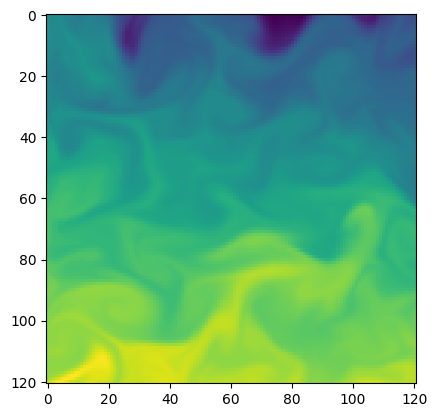

In [ ]:
print(th2d.max(),th2d.min())
print(np.where(np.isnan(th2d)))
plt.imshow(th2d[1])

In [ ]:
date = dt.datetime(2023,1,1)
data_dir = "/content/drive/MyDrive/Ateliershom/previ/"
max_previ = 365
previth2d= np.empty(shape=(max_previ,121,121))
for i in trange(max_previ):
    previth2d[i]=xr.open_dataset(f"{data_dir}glorys12_1day_{date.strftime("%Y-%m-%d")}.nc")[var].isel(depth=0, time=0)
    date += dt.timedelta(days=1)

print (f"{max_previ} files loaded")

print(previth2d.shape)
np.save('/content/drive/MyDrive/Ateliershom/X_previ.npy',previth2d)

100%|██████████| 365/365 [00:17<00:00, 20.64it/s]

365 files loaded
(365, 121, 121)


Maintenant nous pouvons mettre en place le traitement par ACP sur notre dataset. Nous allons viser 99% de VE pour notre reconstruction.

In [40]:
from sklearn.decomposition import PCA
ACP_train = np.load('/content/drive/MyDrive/Ateliershom/ACP_train.npy')
X_previ= np.load('/content/drive/MyDrive/Ateliershom/X_previ.npy')
pca = PCA(n_components=0.99)
pcaglory = pca.fit(ACP_train.reshape(ACP_train.shape[0],-1))
transformglory = pcaglory.transform(X_previ.reshape(X_previ.shape[0],-1))
X_r = pca.inverse_transform(transformglory)

In [ ]:
X_r = X_r.reshape(X_r.shape[0],121,121)

In [ ]:
np.save('/content/drive/MyDrive/Ateliershom/ACP99_previ', X_r)

## 4b) Pré-traitement pour l'IA

En IA, l'étape la plus important est celle de définiton des entrées et des sorties. Ici, nous appliquerons un modèle pour lequel nous connaissons nous input et notre cible. Nous pouvons donc fonctionner sur un apprentissage supervisé.

Dans le cadre d'un AE plusieurs architecture son possible, nous commencerons par mettre en place une première archi basée sur des convolutions uniquement (Auto-Encoder Convolutionnel).

Sachant :

* On connait la résolution d'entrée (121,121)
* On connait la résolution de sortie (121,121)
* On n'impose pas de taille limite sur le bottleneck

Il faut alors commencer par créer ce que l'on appel de Dataloader, qui va nous permettre de "charger" nos données sur les modèles de réseau de neurones.
Nous utiliserons la bibliothèque Pytorch en combinaison avec Pytorch Lightning pour les entrainements.

Pytorch fonctionne avec un type de données que l'on appelle tenseurs (tensor) avec lesquels il nous faut nous familliariser


# 1. PyTorch Tensors

Un **tensor** est la structure de base de PyTorch :  
- similaire à un `ndarray` NumPy,  
- optimisé pour le GPU


### Types de tenseurs courants
- **Tenseur 0D** → scalaire  
- **Tenseur 1D** → vecteur  
- **Tenseur 2D** → matrice  
- **Tenseur 3D+** → images, batches, vidéos, données spatio-temporelles
   
![1_0pRV1-1uNUxLmlvooreVpw.png](https://miro.medium.com/v2/1*0pRV1-1uNUxLmlvooreVpw.png)

Nous allons commencer par créer une data array avec nos données journalière de manière analogue à la transformation précédente.

In [7]:
# avec xr
#ds = xr.open_dataset(f"{data_dir}glorys12_1day_2020-03-28.nc")
var = "thetao"
#var_surface = ds[var].isel(depth=0, time=0)

# === Configuration ===
data_dir = "/content/drive/MyDrive/Ateliershom/train_reduced/"    # <-- modifie ici
max_files = 1008   # mettre un petit nombre pour test rapide (ex: 100)
date = dt.datetime(1993,3,28)
filelist=[]
for i in range(max_files):
    filelist.append(f"{data_dir}glorys12_1day_{date.strftime("%Y-%m-%d")}.nc")
    date += dt.timedelta(days=1)

daTh2D = xr.open_mfdataset(filelist)[var].isel(depth=0)
#print(filelist)

daTh2D
daTh2D=daTh2D.drop_vars("depth")
daTh2D.to_netcdf("/content/drive/MyDrive/Ateliershom/IA_train.nc")

In [8]:
daTh2D

<xarray.DataArray 'thetao' (time: 1008, latitude: 121, longitude: 121)> Size: 118MB
dask.array<getitem, shape=(1008, 121, 121), dtype=float64, chunksize=(1, 121, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8kB 1993-03-28 1993-03-29 ... 1995-12-30
  * latitude   (latitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
  * longitude  (longitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
Attributes:
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    valid_max:      21306
    long_name:      Temperature
    valid_min:      -32766

In [ ]:
#plt.imshow(th2d[5689])
#plt.imshow(daTh2D.isel(time=5689))

In [9]:
#check nan et valeur abérrante
daTh2D.isnull().any()
daTh2D.max()
daTh2D.min()

<xarray.DataArray 'thetao' ()> Size: 8B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    valid_max:      21306
    long_name:      Temperature
    valid_min:      -32766

In [10]:
# avec xr
#ds = xr.open_dataset(f"{data_dir}glorys12_1day_2020-03-28.nc")
var = "thetao"
#var_surface = ds[var].isel(depth=0, time=0)

# === Configuration ===
data_dir = "/content/drive/MyDrive/Ateliershom/previ/"    # <-- modifie ici
max_files = 365   # mettre un petit nombre pour test rapide (ex: 100)
date = dt.datetime(2023,1,1)
filelist=[]
for i in range(max_files):
    filelist.append(f"{data_dir}glorys12_1day_{date.strftime("%Y-%m-%d")}.nc")
    date += dt.timedelta(days=1)

previdaTh2D = xr.open_mfdataset(filelist)[var].isel(depth=0)
#print(filelist)

previdaTh2D
previdaTh2D=previdaTh2D.drop_vars("depth")
previdaTh2D.to_netcdf("/content/drive/MyDrive/Ateliershom/X_previ.nc")

On passe au dataModule

PyTorch Lightning est une **surcouche légère** au-dessus de PyTorch qui :

- structure le code proprement,
- gère automatiquement les boucles d’entraînement,
- facilite l’entraînement sur GPU/TPU/multi-GPU,
- sépare clairement les parties “modèle”, “données”, “optimiseur”.

Lightning impose une structure simple :

1. **`forward()`**  
   - définit le passage avant du modèle (prédictions)

2. **`training_step(batch, batch_idx)`**  
   - définit une étape d’entraînement  
   - retourne une loss

3. **`configure_optimizers()`**  
   - définit l’optimiseur (ex. Adam)

4. **`Trainer.fit()`**  
   - lance tout le processus automatiquement  
   - gère GPUs, logs, callbacks, checkpoints

In [6]:
class NetCDFTimeSliceDataset(Dataset):
    """
    Return each time slice of variable as (1,H,W) normalized tensor.
    """
    def __init__(self, nc_path, var_name, mean, std, fill_value=0.0):
        self.nc_path = nc_path
        self.ds = xr.open_dataset(nc_path)
        self.var_name = var_name
        self.arr = self.ds[var_name]
        self.mean = mean
        self.std = std
        self.fill_value = fill_value
        self.n_time = self.arr.sizes["time"]

    def __len__(self):
        return self.n_time

    def __getitem__(self, idx):
        img = self.arr.isel(time=idx).values.astype("float32")
        img = np.nan_to_num(img, nan=self.fill_value)
        img = (img - self.mean) / (self.std + 1e-8)
        tensor = torch.from_numpy(img).unsqueeze(0)
        return tensor

class OceanDataModule(pl.LightningDataModule):
    def __init__(self, nc_path, var_name=None, batch_size=8, num_workers=2, val_fraction=0.2):
        super().__init__()
        self.nc_path = nc_path
        self.var_name = var_name
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_fraction = val_fraction

    def setup(self, stage=None):
        ds = xr.open_dataset(self.nc_path)

        # choose variable name if unspecified
        if self.var_name is None:
            for v in ds.data_vars:
                if "time" in ds[v].dims:
                    self.var_name = v
                    break

        arr = ds[self.var_name]
        n_time = arr.sizes["time"]
        idxs = np.arange(n_time)

        n_val = int(self.val_fraction * n_time)
        train_idx = idxs[:-n_val]
        val_idx = idxs[-n_val:]

        # compute mean/std on train set
        train_data = arr.isel(time=train_idx).values.astype("float32")
        train_data = np.nan_to_num(train_data, nan=np.nan)
        self.mean = float(np.nanmean(train_data))
        self.std  = float(np.nanstd(train_data))

        full = NetCDFTimeSliceDataset(
            self.nc_path,
            self.var_name,
            mean=self.mean,
            std=self.std,
            fill_value=self.mean
        )

        self.train_dataset = Subset(full, train_idx.tolist())
        self.val_dataset   = Subset(full, val_idx.tolist())

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)


In [47]:
#datamodule
nc_path = "/content/drive/MyDrive/Ateliershom/IA_train.nc"

dm = OceanDataModule(nc_path=nc_path, batch_size=8, val_fraction=0.2)
dm.setup()

print("Variable utilisée :", dm.var_name)
print("Mean =", dm.mean, "Std =", dm.std)
print("Train samples =", len(dm.train_dataset))
print("Val samples =", len(dm.val_dataset))


Variable utilisée : thetao
Mean = 18.356529235839844 Std = 2.693434953689575
Train samples = 807
Val samples = 201


## 4c) Définition du modèle d'AE

In [7]:
#AEconv
class ConvAutoencoder(pl.LightningModule):
    def __init__(self, in_channels=1, base_ch=32, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        ch = base_ch

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU()
        )
        self.down1 = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

        self.enc2 = nn.Sequential(
            nn.Conv2d(ch, ch*2, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch*2, ch*2, 3, padding=1), nn.ReLU()
        )
        self.down2 = nn.Conv2d(ch*2, ch*2, 3, stride=2, padding=1)

        self.enc3 = nn.Sequential(
            nn.Conv2d(ch*2, ch*4, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch*4, ch*4, 3, padding=1), nn.ReLU()
        )
        self.down3 = nn.Conv2d(ch*4, ch*4, 3, stride=2, padding=1)

        # Decoder
        self.up3 = nn.ConvTranspose2d(ch*4, ch*4, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.Sequential(nn.Conv2d(ch*4, ch*2, 3, padding=1), nn.ReLU())

        self.up2 = nn.ConvTranspose2d(ch*2, ch*2, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(ch*2, ch, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(ch, ch, 3, stride=2, padding=1, output_padding=1)
        self.dec1 = nn.Conv2d(ch, in_channels, 3, padding=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.down1(x1))
        x3 = self.enc3(self.down2(x2))
        z  = self.down3(x3)

        d3 = F.interpolate(self.up3(z), size=x3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(d3)

        d2 = F.interpolate(self.up2(d3), size=x2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(d2)

        d1 = F.interpolate(self.up1(d2), size=x1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(d1)
        return out

    def training_step(self, batch, batch_idx):
        x = batch
        xhat = self(x)
        loss = F.mse_loss(xhat, x)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch
        xhat = self(x)
        loss = F.mse_loss(xhat, x)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


## 4d) Entrainement de notre modèle et visualisation des sorties

In [8]:
model_name = "ae"   # "ae" ou "unet"
model = ConvAutoencoder(base_ch=32, lr=1e-3)
model

ConvAutoencoder(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (down1): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (down2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (down3): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (up3): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dec3): Seque

In [9]:
checkpoint_cb = ModelCheckpoint(
    dirpath="checkpoints",
    save_top_k=1,
    monitor="val_loss",
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    callbacks=[checkpoint_cb,TQDMProgressBar(refresh_rate=1)],
    deterministic=True
)

trainer.fit(model, dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ enc1  │ Sequential      │  9.6 K │ train │     0 │
│ 1  │ down1 │ Conv2d          │  9.2 K │ train │     0 │
│ 2  │ enc2  │ Sequential      │ 55.4 K │ train │     0 │
│ 3  │ down2 │ Conv2d          │ 36.9 K │ train │     0 │
│ 4  │ enc3  │ Sequential      │  221 K │ train │     0 │
│ 5  │ down3 │ Conv2d          │  147 K │ train │     0 │
│ 6  │ up3   │ ConvTranspose2d │  147 K │ train │     0 │
│ 7  │ dec3  │ Sequential      │ 73.8 K │ train │     0 │
│ 8  │ up2   │ ConvTranspose2d │ 36.9 K │ train │     0 │
│ 9  │ dec2  │ Sequential      │ 18.5 K │ train │     0 │
│ 10 │ up1   │ ConvTranspose2d │  9.2 K │ train │     0 │
│ 11 │ dec1  │ Conv2d          │    289 │ train │     0 │
└────┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 766 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 766 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


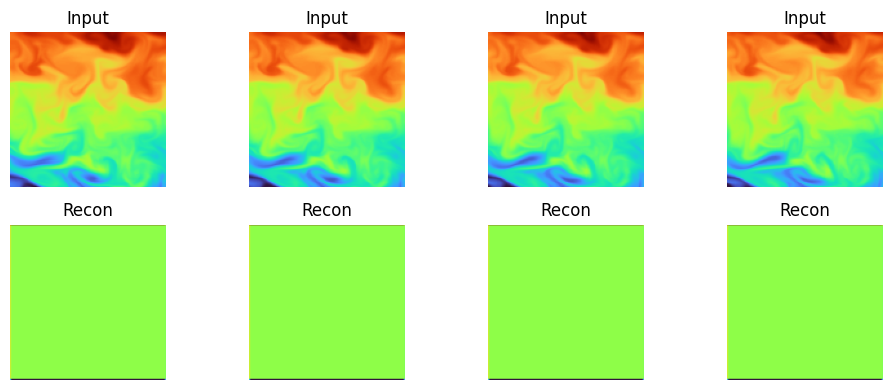

In [10]:
# récupération d'un batch
batch = next(iter(dm.val_dataloader()))
model.eval()
with torch.no_grad():
    recon = model(batch)

# dénormalisation
x = batch.numpy()
xhat = recon.numpy()

def denorm(t):
    return t * dm.std + dm.mean

plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(denorm(x[i,0]), origin="lower",cmap="turbo")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(denorm(xhat[i,0]), origin="lower",cmap="turbo")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

Notre modèle semble montrer une incapacité a résoudre notre problématique. Nous allons donc passer à une configuration plus avancée, un U-Net

## 4e) U-net Implémentation et entrainement


Le **U-Net** est un réseau de neurones convolutionnel conçu initialement pour la segmentation d’images, mais il s’avère extrêmement performant pour toutes les tâches de **reconstruction spatiale détaillée**, notamment les cartes géophysiques telles que les températures de surface de l'océan (SST).


A l'imae d'un AE un U-net est composé de deux chemins : encodage et décodage

**A. Encodeur**  
Il extrait des caractéristiques de plus en plus complexes :

$
h_{i+1} = \text{Conv}\big( \text{Downsample}(h_i) \big)
$

- Chaque étape réduit la résolution (pooling ou stride).
- Les filtres capturent les structures méso-echelles.

**B. Décodeur**  
Il reconstruit l’image en augmentant progressivement la résolution :

$
\hat{h}_{i} = \text{Conv}\big( \text{Upsample}(h_{i+1}) \oplus h_i^{\text{skip}} \big)
$

où :

- $ ( \oplus ) $ représente la **concaténation avec un skip connection**,
- $ ( h_i^{\text{skip}} ) $ est la carte de caractéristiques correspondante venant de l’encodeur.

---

**les *skip connections***

Les skip connections permettent :

$
\hat{x} = f_{\text{decoder}}\big(z, \{h_i^{\text{skip}}\}\big)
$

Elles transmettent directement les fines-échelles de l’encodeur au décodeur, évitant de les perdre dans la compression.

Dans notre cas un Ae classique va confondre les différentes echelles et les mélanger, sans réussir à la reconstruire chacunes à leurs niveau.

Les U-Net le font très bien grâce à la concaténation multi-résolution :

$
\text{Edges}_{\text{high res}} \in h_i^{\text{skip}}
$

Cela évite les reconstructions trop lissées.

![olumetric-scheme-of-3D-U-Net-which-applies-an-end-to-end-architecture-The-kernel-of.png](attachment:2d02eab4-54ce-40c9-a677-b8dd2227035f.png)

In [7]:
class UNet(pl.LightningModule):
    def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256], lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        # ------- Encoder -------
        self.down_blocks = nn.ModuleList()
        self.pools = nn.ModuleList()

        channels = in_channels
        for f in features:
            self.down_blocks.append(
                nn.Sequential(
                    nn.Conv2d(channels, f, kernel_size=3, padding=1),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(f, f, kernel_size=3, padding=1),
                    nn.ReLU(inplace=True),
                )
            )
            self.pools.append(nn.MaxPool2d(2))
            channels = f

        # ------- Bottleneck -------
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features[-1], features[-1]*2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(features[-1]*2, features[-1]*2, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # ------- Decoder -------
        self.up_transpose = nn.ModuleList()
        self.up_blocks = nn.ModuleList()

        decoder_feats = features[::-1]

        channels = features[-1]*2
        for f in decoder_feats:
            self.up_transpose.append(
                nn.ConvTranspose2d(channels, f, kernel_size=2, stride=2)
            )
            self.up_blocks.append(
                nn.Sequential(
                    nn.Conv2d(f*2, f, 3, padding=1),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(f, f, 3, padding=1),
                    nn.ReLU(inplace=True),
                )
            )
            channels = f

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        out = x

        # ------- Encode -------
        for down, pool in zip(self.down_blocks, self.pools):
            out = down(out)
            skips.append(out)
            out = pool(out)

        # ------- Bottleneck -------
        out = self.bottleneck(out)

        # ------- Decode -------
        skips = skips[::-1]

        for up, block, skip in zip(self.up_transpose, self.up_blocks, skips):
            out = up(out)
            # On "fixe" la taille si nécessaire
            out = F.interpolate(out, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            out = torch.cat([skip, out], dim=1)
            out = block(out)

        return self.final(out)

    def encode(self, x):
        skips = []
        out = x

        for down, pool in zip(self.down_blocks, self.pools):
            out = down(out)
            skips.append(out)
            out = pool(out)

        # bottleneck
        out = self.bottleneck(out)
        return out

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

    def training_step(self, batch, batch_idx):
        pred = self(batch)
        loss = F.mse_loss(pred, batch)
        self.log("train_loss", loss)
        return loss


Entrainement de notre modèle pour le même DataModel

In [8]:
model_name = "unet"   # "ae" ou "unet"

if model_name == "ae":
    model = ConvAutoencoder(base_ch=32, lr=1e-3)
else:
    model = UNet()

model

UNet(
  (down_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
 

In [10]:
checkpoint_cb = ModelCheckpoint(
    dirpath="checkpoints",
    save_top_k=1,
    monitor="val_loss",
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    callbacks=[checkpoint_cb,TQDMProgressBar(refresh_rate=1)],
    deterministic=True
)

trainer.fit(model, dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ down_blocks  │ ModuleList │  1.2 M │ train │     0 │
│ 1 │ pools        │ ModuleList │      0 │ train │     0 │
│ 2 │ bottleneck   │ Sequential │  3.5 M │ train │     0 │
│ 3 │ up_transpose │ ModuleList │  696 K │ train │     0 │
│ 4 │ up_blocks    │ ModuleList │  2.4 M │ train │     0 │
│ 5 │ final        │ Conv2d     │     33 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 M                                                                                                
Total estimated model params size (MB): 31                                                                         
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:588: `ModelCheckpoint(monitor='val_loss')` could not find the monitored key in the returned metrics: ['train_loss', 'epoch', 'step']. HINT: Did you call `log('val_loss', value)` in the `LightningModule`?
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


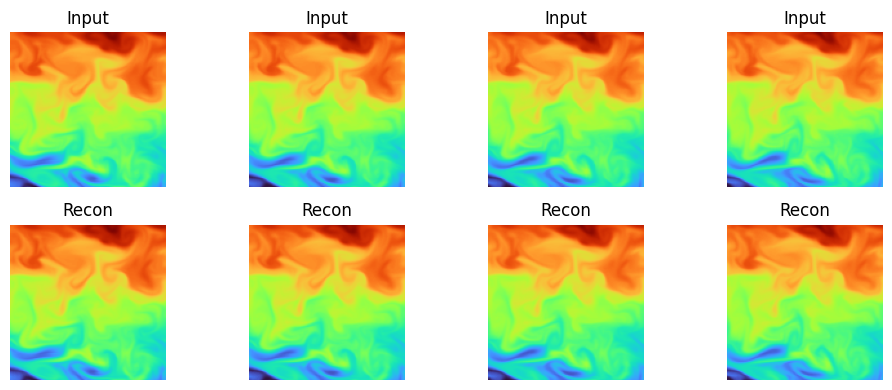

In [11]:
# récupération d'un batch
batch = next(iter(dm.val_dataloader()))
model.eval()
with torch.no_grad():
    recon = model(batch)

# dénormalisation
x = batch.numpy()
xhat = recon.numpy()

def denorm(t):
    return t * dm.std + dm.mean

plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(denorm(x[i,0]), origin="lower",cmap="turbo")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(denorm(xhat[i,0]), origin="lower",cmap="turbo")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

def latent_size(tensor):
    return np.prod(tensor.shape[1:])  # ignore batch

latent_unet = model.encode(batch)

Le modèle semble donner de meilleurs résultats, nous allons conserver celui-ci pour l'analyse et le comparatif

# 5 Réalisation du comparatif, traitement des résultats

In [13]:
# pour sauver les poids du modèle
#trainer.save_checkpoint("/content/drive/MyDrive/Ateliershom/unet.ckpt")

# Pour charger le modèle avec les poids sauvegardés
#model = UNet.load_from_checkpoint("unet.ckpt") charger le modele
#model.eval()

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


On charge le jeu de données d'inférence que l'on a mis de coté, a savoir un an de mesure de température (2023)

In [48]:
previ_nc = "/content/drive/MyDrive/Ateliershom/X_previ.nc"
var_name = dm.var_name

# Lecture
ds_previ = xr.open_dataset(previ_nc)
data_previ = ds_previ[var_name].values  # (time, lat, lon)
print("Forme fichier prévi :", data_previ.shape)

# Normalisation avec les stats du DataModule
data_previ_norm = (data_previ - dm.mean) / dm.std

# Conversion en tenseur PyTorch (B,C,H,W)
tensor_previ = torch.tensor(data_previ_norm[:, None, :, :], dtype=torch.float32)

Forme fichier prévi : (365, 121, 121)


In [15]:
model.eval()
with torch.no_grad():
    recon_previ = model(tensor_previ)

In [16]:
def denorm(t):
    return t * dm.std + dm.mean

x = tensor_previ.cpu().numpy()
xhat = recon_previ.cpu().numpy()

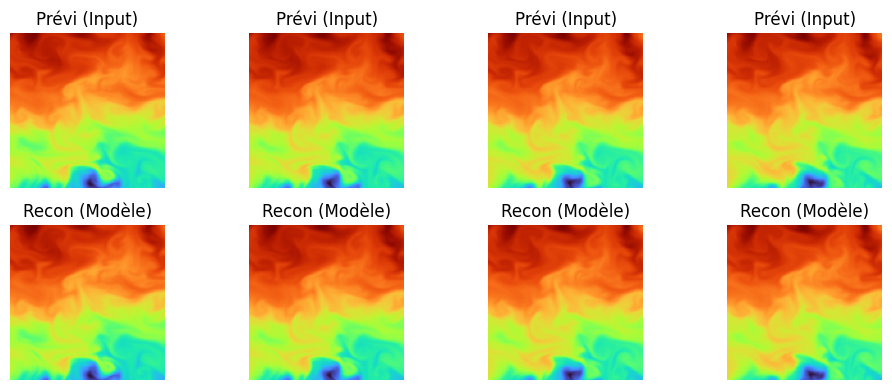

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
n = min(4, x.shape[0])

for i in range(4):
    plt.subplot(2, n, i+1)
    plt.imshow(denorm(x[i,0]), origin="lower", cmap="turbo")
    plt.title("Prévi (Input)")
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(denorm(xhat[i,0]), origin="lower", cmap="turbo")
    plt.title("Recon (Modèle)")
    plt.axis("off")

plt.tight_layout()
plt.show()

On replace les sortie du modèle en np array pour la suite de l'exercice et faciliter les traitement d'image et de statistiques

In [18]:
xhatdenorm=denorm(xhat)
xdenorm=denorm(x)
xhatdenorm=xhatdenorm.reshape(xhatdenorm.shape[0],xhatdenorm.shape[2],xhatdenorm.shape[3])
xdenorm=xdenorm.reshape(xdenorm.shape[0],xdenorm.shape[2],xdenorm.shape[3])

In [24]:
#np.save('input_previ' , xdenorm)
np.save('/content/drive/MyDrive/Ateliershom/unet_previ' , xhatdenorm)

# Si vous ne voulez que les résultats vous pouvers lancer à partir d'ici !

In [22]:
def plot_original_and_reconstruction(original: np.ndarray, recon: np.ndarray, vmin=None, vmax=None, cmap='turbo'):
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    im0 = ax[0].imshow(original, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[0].set_title('Original')
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(recon, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[1].set_title('Reconstruction')
    plt.colorbar(im1, ax=ax[1], fraction=0.046)
    plt.tight_layout()
    plt.show()

def plot_anomalies_and_error(field, recon, climatology, clim_vmax=None):
    anom_true = field - climatology
    anom_recon = recon - climatology
    anom_residual = anom_true - anom_recon

    v = clim_vmax if clim_vmax is not None else max(np.nanmax(np.abs(anom_true)), np.nanmax(np.abs(anom_residual)))
    fig, axs = plt.subplots(1,4, figsize=(20,5))
    axs[0].imshow(field, cmap='turbo'); axs[0].set_title('Original')
    axs[1].imshow(recon, cmap='turbo'); axs[1].set_title('Reconstruction')
    im2 = axs[2].imshow(anom_true, cmap='coolwarm', vmin=-v, vmax=v); axs[2].set_title('Anomalie originale')
    im3 = axs[3].imshow(anom_residual, cmap='coolwarm', vmin=-v, vmax=v); axs[3].set_title('Anomalie reconstruite')
    plt.colorbar(im2, ax=axs[2], fraction=0.046)
    plt.colorbar(im3, ax=axs[3], fraction=0.046)
    plt.tight_layout()
    plt.show()

def rmse_map(field, recon):
    return np.sqrt((field - recon)**2)

def radial_spectrum(field):
    F = np.fft.fftshift(np.abs(np.fft.fft2(field)))
    ny, nx = F.shape
    y, x = np.indices((ny, nx))
    r = np.sqrt((x - nx/2)**2 + (y - ny/2)**2).astype(int)
    denom = np.bincount(r.ravel())
    numer = np.bincount(r.ravel(), F.ravel())
    radial_mean = numer / (denom + 1e-12)
    return radial_mean


In [25]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def compare_unet_vs_pca(originals, unet_recons, pca_recons):
    """
    Interface interactive pour comparer :
    - Original
    - Reconstruction U-Net
    - Reconstruction PCA
    - Erreurs correspondantes
    """

    T = originals.shape[0]

    @interact(t=IntSlider(min=0, max=T-1, step=1, value=0))
    def _show(t):
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))

        # ORIGINAL
        ax = axes[0,0]
        im = ax.imshow(originals[t], origin="lower",cmap="turbo")
        ax.set_title("Original")
        plt.colorbar(im, ax=ax)

        # U-NET
        ax = axes[0,1]
        im = ax.imshow(unet_recons[t], origin="lower",cmap="turbo")
        ax.set_title("U-Net Reconstruction")
        plt.colorbar(im, ax=ax)

        # PCA
        ax = axes[0,2]
        im = ax.imshow(pca_recons[t], origin="lower",cmap="turbo")
        ax.set_title("PCA Reconstruction")
        plt.colorbar(im, ax=ax)

        # ERROR U-NET
        err_unet = originals[t] - unet_recons[t]
        ax = axes[1,0]
        im = ax.imshow(err_unet, origin="lower")
        ax.set_title(f"Erreur U-Net (RMSE={rmse(originals[t], unet_recons[t]):.4f})")
        plt.colorbar(im, ax=ax)

        # ERROR PCA
        err_pca = originals[t] - pca_recons[t]
        ax = axes[1,1]
        im = ax.imshow(err_pca, origin="lower")
        ax.set_title(f"Erreur PCA (RMSE={rmse(originals[t], pca_recons[t]):.4f})")
        plt.colorbar(im, ax=ax)

        # DIFFERENCE AE - PCA
        ax = axes[1,2]
        diff = np.abs(err_unet) - np.abs(err_pca)
        im = ax.imshow(diff, origin="lower")
        ax.set_title("U-Net error - PCA error")
        plt.colorbar(im, ax=ax)

        plt.tight_layout()
        plt.show()


In [26]:
def model_size_mb(model):
    torch.save(model.state_dict(), "/tmp/tmp.pt")
    size = os.path.getsize("/tmp/tmp.pt") / (1024*1024)
    return size

def compare_sizes(model, latent_dim, pca):
    print("=== Taille ===")
    print(f"U-Net : {model_size_mb(model):.2f} MB")
    print(f"PCA vecteurs propres : {pca.components_.nbytes/(1024*1024):.2f} MB")
    print()
    print("=== Dimension latente ===")
    print(f"U-Net latent dim : {latent_dim}")
    print(f"PCA n_components : {pca.n_components_}")
    print()
    print("Valeurs propres PCA :")
    print(pca.explained_variance_)


In [27]:
date = dt.datetime(2023,1,1)
date_previ=[]
for i in range(365):
    date_previ.append(date)
    date += dt.timedelta(days=1)

In [28]:
print(date_previ)

[datetime.datetime(2023, 1, 1, 0, 0), datetime.datetime(2023, 1, 2, 0, 0), datetime.datetime(2023, 1, 3, 0, 0), datetime.datetime(2023, 1, 4, 0, 0), datetime.datetime(2023, 1, 5, 0, 0), datetime.datetime(2023, 1, 6, 0, 0), datetime.datetime(2023, 1, 7, 0, 0), datetime.datetime(2023, 1, 8, 0, 0), datetime.datetime(2023, 1, 9, 0, 0), datetime.datetime(2023, 1, 10, 0, 0), datetime.datetime(2023, 1, 11, 0, 0), datetime.datetime(2023, 1, 12, 0, 0), datetime.datetime(2023, 1, 13, 0, 0), datetime.datetime(2023, 1, 14, 0, 0), datetime.datetime(2023, 1, 15, 0, 0), datetime.datetime(2023, 1, 16, 0, 0), datetime.datetime(2023, 1, 17, 0, 0), datetime.datetime(2023, 1, 18, 0, 0), datetime.datetime(2023, 1, 19, 0, 0), datetime.datetime(2023, 1, 20, 0, 0), datetime.datetime(2023, 1, 21, 0, 0), datetime.datetime(2023, 1, 22, 0, 0), datetime.datetime(2023, 1, 23, 0, 0), datetime.datetime(2023, 1, 24, 0, 0), datetime.datetime(2023, 1, 25, 0, 0), datetime.datetime(2023, 1, 26, 0, 0), datetime.datetime(20

In [29]:
def month_to_season(month):
    if month in (12, 1, 2):
        return "DJF"
    elif month in (3, 4, 5):
        return "MAM"
    elif month in (6, 7, 8):
        return "JJA"
    else:
        return "SON"

In [30]:
def compute_rmse_and_ve(originals, recons):
    """
    originals, recons : (T, H, W)
    """
    T = originals.shape[0]
    rmse_list = []
    ve_list = []

    for t in range(T):
        o = originals[t]
        r = recons[t]
        err = o - r

        rmse_val = np.sqrt(np.mean(err**2))

        var_o = np.var(o)
        var_e = np.var(err)
        ve_val = 1 - var_e / var_o if var_o > 0 else 0

        rmse_list.append(rmse_val)
        ve_list.append(ve_val)

    return rmse_list, ve_list


In [31]:
def compute_global_and_seasonal_stats(dates, rmse_unet, rmse_pca, ve_unet, ve_pca):
    """
    dates : liste de datetimes OU objets avec un attribut .month
    """

    # containers saisonniers
    seasons = {
        "DJF": {"rmse_unet": [], "rmse_pca": [], "ve_unet": [], "ve_pca": []},
        "MAM": {"rmse_unet": [], "rmse_pca": [], "ve_unet": [], "ve_pca": []},
        "JJA": {"rmse_unet": [], "rmse_pca": [], "ve_unet": [], "ve_pca": []},
        "SON": {"rmse_unet": [], "rmse_pca": [], "ve_unet": [], "ve_pca": []},
    }

    # remplissage saison
    for i, d in enumerate(dates):
        season = month_to_season(d.month)
        seasons[season]["rmse_unet"].append(rmse_unet[i])
        seasons[season]["rmse_pca"].append(rmse_pca[i])
        seasons[season]["ve_unet"].append(ve_unet[i])
        seasons[season]["ve_pca"].append(ve_pca[i])

    # moyenne globale
    global_stats = {
        "RMSE_UNET": np.mean(rmse_unet),
        "RMSE_PCA": np.mean(rmse_pca),
        "VE_UNET": np.mean(ve_unet),
        "VE_PCA": np.mean(ve_pca),
    }

    # moyennes saisonnières
    seasonal_stats = {}
    for s in seasons:
        seasonal_stats[s] = {
            "RMSE_UNET": np.mean(seasons[s]["rmse_unet"]) if seasons[s]["rmse_unet"] else None,
            "RMSE_PCA":  np.mean(seasons[s]["rmse_pca"])  if seasons[s]["rmse_pca"] else None,
            "VE_UNET":   np.mean(seasons[s]["ve_unet"])   if seasons[s]["ve_unet"] else None,
            "VE_PCA":    np.mean(seasons[s]["ve_pca"])    if seasons[s]["ve_pca"] else None,
        }

    return global_stats, seasonal_stats


In [32]:
def print_metrics_table(global_stats, seasonal_stats):
    print("\n==== GLOBAL ====")
    print(f"{'Metric':<12} | {'U-Net':>10} | {'PCA':>10}")
    print("-"*38)
    print(f"{'RMSE':<12} | {global_stats['RMSE_UNET']:10.4f} | {global_stats['RMSE_PCA']:10.4f}")
    print(f"{'VE':<12}   | {global_stats['VE_UNET']:10.4f} | {global_stats['VE_PCA']:10.4f}")

    print("\n==== SEASONAL ====")
    print(f"{'Season':<8} | {'RMSE_UNET':>10} | {'RMSE_PCA':>10} | {'VE_UNET':>10} | {'VE_PCA':>10}")
    print("-"*70)
    for s in ["DJF", "MAM", "JJA", "SON"]:
        ss = seasonal_stats[s]
        print(f"{s:<8} | {ss['RMSE_UNET']:10.4f} | {ss['RMSE_PCA']:10.4f} | {ss['VE_UNET']:10.4f} | {ss['VE_PCA']:10.4f}")
def latent_size(tensor):
    return np.prod(tensor.shape[1:])  # ignore batch


In [33]:
def latent_size(tensor):
    return np.prod(tensor.shape[1:])  # ignore batch

latent_unet = model.encode(batch)

In [45]:
Xhat_ACP=np.load('/content/drive/MyDrive/Ateliershom/ACP99_previ.npy')
X_previ=np.load('/content/drive/MyDrive/Ateliershom/X_previ.npy')
Xhat_unet=np.load('/content/drive/MyDrive/Ateliershom/unet_previ.npy')

In [46]:
compare_unet_vs_pca(X_previ,Xhat_unet,Xhat_ACP)

interactive(children=(IntSlider(value=0, description='t', max=364), Output()), _dom_classes=('widget-interact'…

In [41]:
# calcul journalier U-Net
rmse_unet, ve_unet = compute_rmse_and_ve(X_previ, Xhat_final)

# calcul journalier PCA
rmse_pca,  ve_pca  = compute_rmse_and_ve(X_previ, Xhat_PCA)
latent_unet = model.encode(batch)
# statistiques globales et saisonnières
global_stats, seasonal_stats = compute_global_and_seasonal_stats(
    dates=date_previ,
    rmse_unet=rmse_unet,
    rmse_pca=rmse_pca,
    ve_unet=ve_unet,
    ve_pca=ve_pca
)


# affichage propre
print_metrics_table(global_stats, seasonal_stats)

print("=== Taille ===")
print(f"U-Net : {model_size_mb(model):.2f} MB")
print(f"PCA vecteurs propres : {pca.components_.nbytes/(1024*1024):.2f} MB")
print()
print("=== Dimension latente ===")
print(f"PCA n_components : {pca.n_components_}")
print("PCA latent (kB) =", transformglory[0].nbytes/ 1024.0, " Kb")
print("UNet latent (kB) =", latent_size(latent_unet) * 4 / 1024, " Kb")


==== GLOBAL ====
Metric       |      U-Net |        PCA
--------------------------------------
RMSE         |     0.0228 |     0.4494
VE             |     0.9999 |     0.9418

==== SEASONAL ====
Season   |  RMSE_UNET |   RMSE_PCA |    VE_UNET |     VE_PCA
----------------------------------------------------------------------
DJF      |     0.0217 |     0.3918 |     0.9998 |     0.9495
MAM      |     0.0191 |     0.4345 |     0.9999 |     0.9447
JJA      |     0.0241 |     0.4964 |     0.9999 |     0.9303
SON      |     0.0262 |     0.4740 |     0.9999 |     0.9428
=== Taille ===
U-Net : 29.61 MB
PCA vecteurs propres : 9.38 MB

=== Dimension latente ===
PCA n_components : 84
PCA latent (kB) = 0.65625  Kb
UNet latent (kB) = 98.0  Kb
